# NB-based Normative Model CV Performance Comparison
평가 지표: **Anderson-Darling subsampled statistic** (n=200, B=100 중앙값), z-score mean/std/skew/kurt, fold 성공률

In [25]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

CV_DIR = Path('CV_Results')

# ── Load available results ─────────────────────────────────────────
def load_if_exists(path):
    return pd.read_csv(path) if path.exists() else None

nb   = load_if_exists(CV_DIR / 'cv_gamlss_stats.csv')
zinb = load_if_exists(CV_DIR / 'cv_zinb_stats.csv')
logr = load_if_exists(CV_DIR / 'cv_logistic_stats.csv')

for name, df in [('NBI', nb), ('ZINBI', zinb), ('Logistic', logr)]:
    if df is not None:
        print(f'{name:10s}: {len(df):6,} genes loaded')
    else:
        print(f'{name:10s}: not found')

NBI       : 15,185 genes loaded
ZINBI     : 15,185 genes loaded
Logistic  :  2,762 genes loaded


## 1. 전체 요약 테이블

In [26]:
# Unified column mapping per model
def extract_metrics(df, label, ad_col, ad_pass_col, mz_col, sz_col, sk_col, ku_col, success_col, flag_col=None):
    if df is None:
        return None
    d = pd.DataFrame({
        'model':        label,
        'gene':         df['gene'],
        'det_rate':     df['det_rate_hc'],
        'ad_sub':       df[ad_col],
        'ad_pass':      df[ad_pass_col].astype(bool),
        'mean_z':       df[mz_col],
        'std_z':        df[sz_col],
        'skew_z':       df[sk_col],
        'kurt_z':       df[ku_col],
        'fold_ok':      df[success_col],
        'any_flag':     df[flag_col].astype(bool) if flag_col and flag_col in df.columns else False,
        'n_removed':    df['n_removed'] if 'n_removed' in df.columns else 0,
    })
    return d

frames = []
if nb is not None:
    frames.append(extract_metrics(nb,   'NBI',
        'ad_sub_stat', 'ad_sub_pass', 'mean_z', 'std_z', 'skew_z', 'kurt_z',
        'fold_success_rate', None))
if zinb is not None:
    frames.append(extract_metrics(zinb, 'ZINBI',
        'ads_full', 'ads_full_pass', 'mean_full_z', 'std_full_z',
        'skew_full_z', 'kurt_full_z', 'fold_success_rate', 'any_flag'))
if logr is not None:
    frames.append(extract_metrics(logr, 'Logistic',
        'ad_sub_stat', 'ad_sub_pass', 'mean_z', 'std_z', 'skew_z', 'kurt_z',
        'fold_success_rate', 'any_flag'))

all_df = pd.concat(frames, ignore_index=True)

# Summary table
summary = all_df.groupby('model').agg(
    n_genes        = ('gene',      'count'),
    ad_pass_rate   = ('ad_pass',   'mean'),
    fold_ok_rate   = ('fold_ok',   'mean'),
    median_ad_sub  = ('ad_sub',    'median'),
    median_mean_z  = ('mean_z',    lambda x: x.median()),
    median_std_z   = ('std_z',     'median'),
    median_skew_z  = ('skew_z',    'median'),
    median_kurt_z  = ('kurt_z',    'median'),
    flag_rate      = ('any_flag',  'mean'),
).round(4)

summary.columns = ['# genes', 'AD pass %', 'Fold ok %',
                   'Median AD_sub', 'Median mean_z', 'Median std_z',
                   'Median skew_z', 'Median kurt_z', 'Flag %']
summary[['AD pass %', 'Fold ok %', 'Flag %']] = (summary[['AD pass %', 'Fold ok %', 'Flag %']] * 100).round(1)
summary

,# genes,AD pass %,Fold ok %,Median AD_sub,Median mean_z,Median std_z,Median skew_z,Median kurt_z,Flag %
model,,,,,,,,,
Logistic,2762,100.0,100.0,0.3624,0.0065,0.9797,0.0711,0.1592,0.4
NBI,15185,89.5,99.6,0.6043,0.0055,1.0456,-0.1388,0.7897,0.0
ZINBI,15185,93.7,99.3,0.4656,0.0152,1.0184,0.1686,0.4540,45.9


## 2. AD Subsampled 통계량 분포 (정규성 적합도)

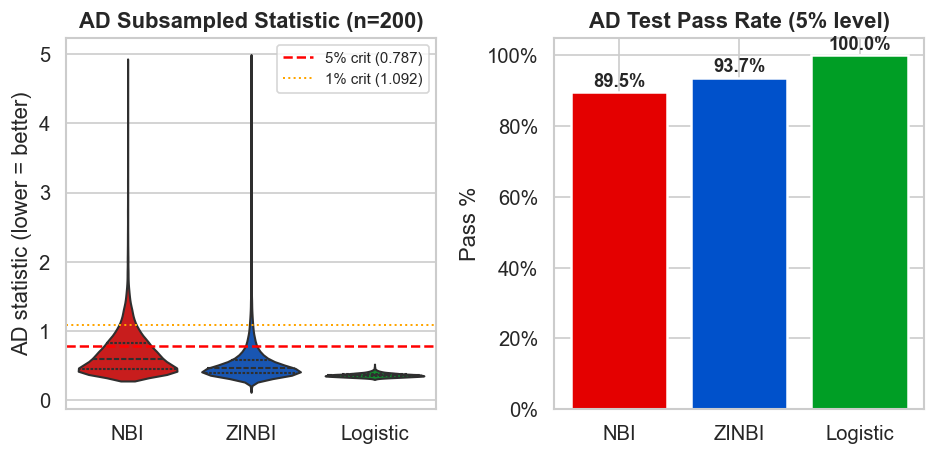

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
palette   = {'NBI': "#E40000", 'ZINBI': "#0051CB", 'Logistic': "#009E25"}
models_present = [m for m in ['NBI', 'ZINBI', 'Logistic']
                  if m in all_df['model'].unique()]

# ── Violin: AD sub distribution ──────────────────────────────────
ax = axes[0]
plot_df = all_df[all_df['ad_sub'].between(0, 5)]
sns.violinplot(data=plot_df, x='model', y='ad_sub', order=models_present,
               palette=palette, inner='quartile', cut=0, ax=ax)
ax.axhline(0.787, color='red', lw=1.5, ls='--', label='5% crit (0.787)')
ax.axhline(1.092, color='orange', lw=1.2, ls=':', label='1% crit (1.092)')
ax.set_title('AD Subsampled Statistic (n=200)', fontweight='bold')
ax.set_xlabel(''); ax.set_ylabel('AD statistic (lower = better)')
ax.legend(fontsize=9)

# ── Bar: AD pass rate ─────────────────────────────────────────────
ax = axes[1]
pass_rates = all_df.groupby('model')['ad_pass'].mean().reindex(models_present) * 100
bars = ax.bar(pass_rates.index, pass_rates.values,
              color=[palette[m] for m in pass_rates.index], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, pass_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_ylim(0, 105)
ax.set_title('AD Test Pass Rate (5% level)', fontweight='bold')
ax.set_ylabel('Pass %'); ax.set_xlabel('')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_ad_comparison.png', bbox_inches='tight')
plt.show()

## 3. Z-score 보정 품질 (mean, std)

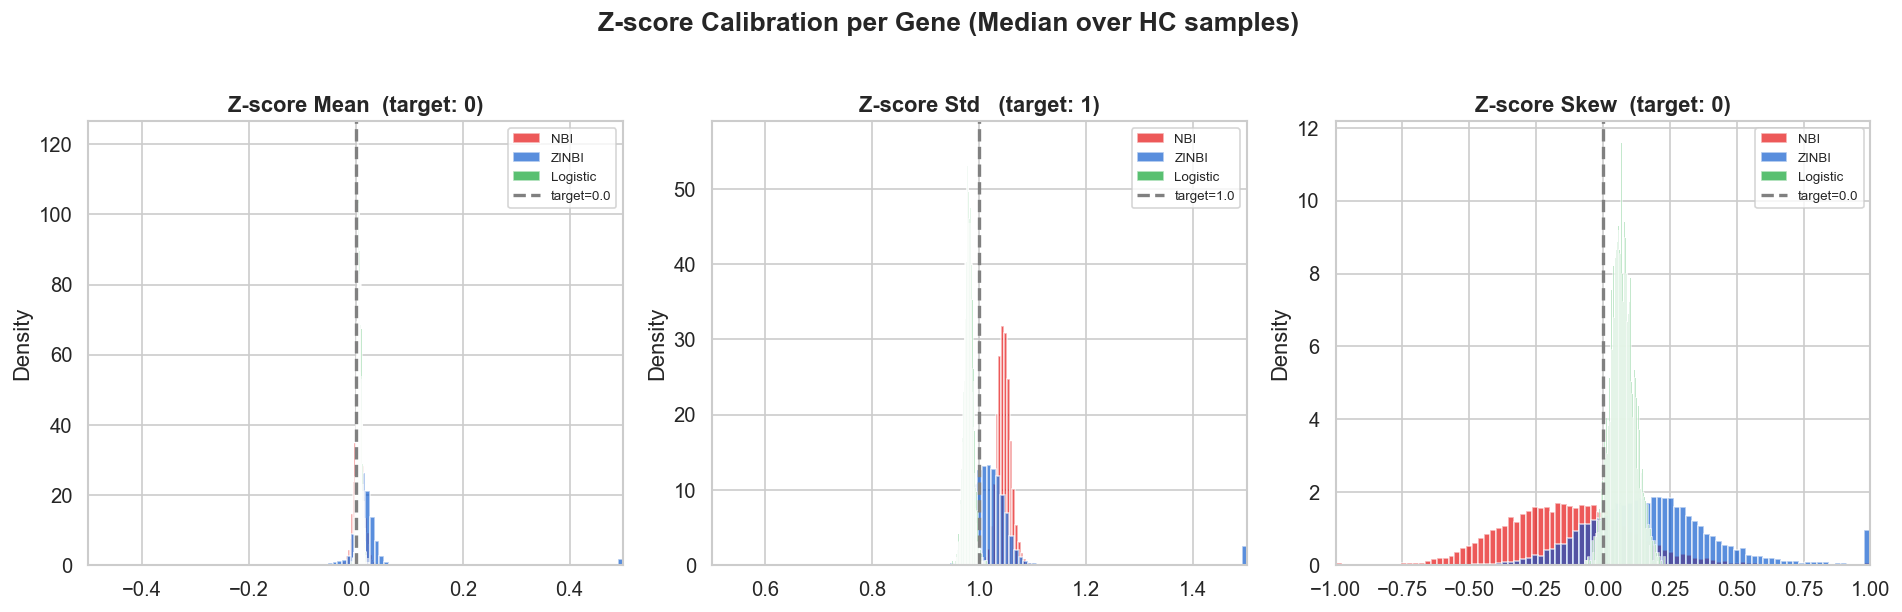

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [
    ('mean_z',  'Z-score Mean  (target: 0)',  (-0.5, 0.5),    0.0,  'grey'),
    ('std_z',   'Z-score Std   (target: 1)',  (0.5, 1.5), 1.0,  'grey'),
    ('skew_z',  'Z-score Skew  (target: 0)',  (-1, 1),    0.0,  'grey'),
]

for ax, (col, title, xlim, target, tcolor) in zip(axes, metrics):
    for model in models_present:
        vals = all_df.loc[all_df['model'] == model, col].dropna()
        vals_clipped = vals.clip(*xlim)
        ax.hist(vals_clipped, bins=90, alpha=0.65, label=model,
                color=palette[model], density=True)
    ax.axvline(target, color=tcolor, lw=2, ls='--', label=f'target={target}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(*xlim)
    ax.legend(fontsize=8)
    ax.set_xlabel(''); ax.set_ylabel('Density')

plt.suptitle('Z-score Calibration per Gene (Median over HC samples)', y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_zscore_calibration.png', bbox_inches='tight')
plt.show()

## 4. Detection rate별 AD 성능 (모델별 커버리지)

In [29]:
models_present

['NBI', 'ZINBI', 'Logistic']

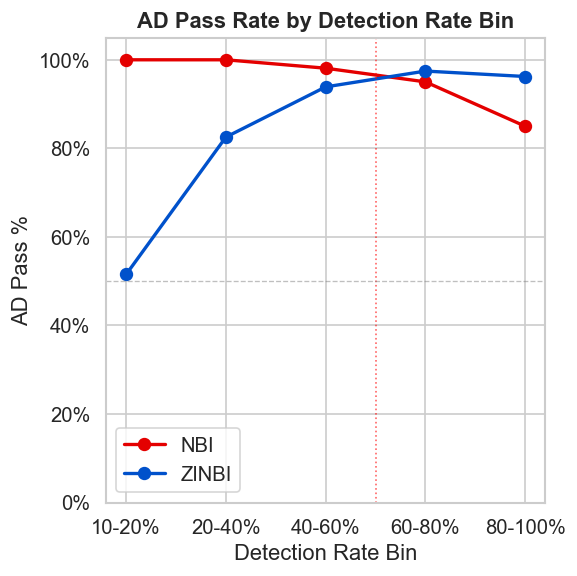

In [30]:
fig, ax = plt.subplots(figsize=(5, 5))

# Bin by detection rate
bins = np.array([0, 0.01, 0.05, 0.10, 0.20, 0.40, 0.60, 0.80, 1.01])
labels = ['0-1%','1-5%','5-10%','10-20%','20-40%','40-60%','60-80%','80-100%']

for model in ['NBI', 'ZINBI']:
    sub = all_df[all_df['model'] == model].copy()
    sub['det_bin'] = pd.cut(sub['det_rate'], bins=bins, labels=labels, right=False)
    pass_by_bin = sub.groupby('det_bin', observed=True)['ad_pass'].mean() * 100
    ax.plot(pass_by_bin.index, pass_by_bin.values, 'o-',
            label=model, color=palette[model], lw=2, ms=7)

ax.axvline(2.5, color='red', lw=1, ls=':', alpha=0.6)  # det_rate=10% boundary (between bin 2 and 3)
ax.axhline(50, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_title('AD Pass Rate by Detection Rate Bin', fontweight='bold')
ax.set_ylabel('AD Pass %')
ax.set_xlabel('Detection Rate Bin')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, 105)
ax.legend()
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_ad_by_detrate.png', bbox_inches='tight')
plt.show()

## 5. Fold 성공률 & Outlier 제거

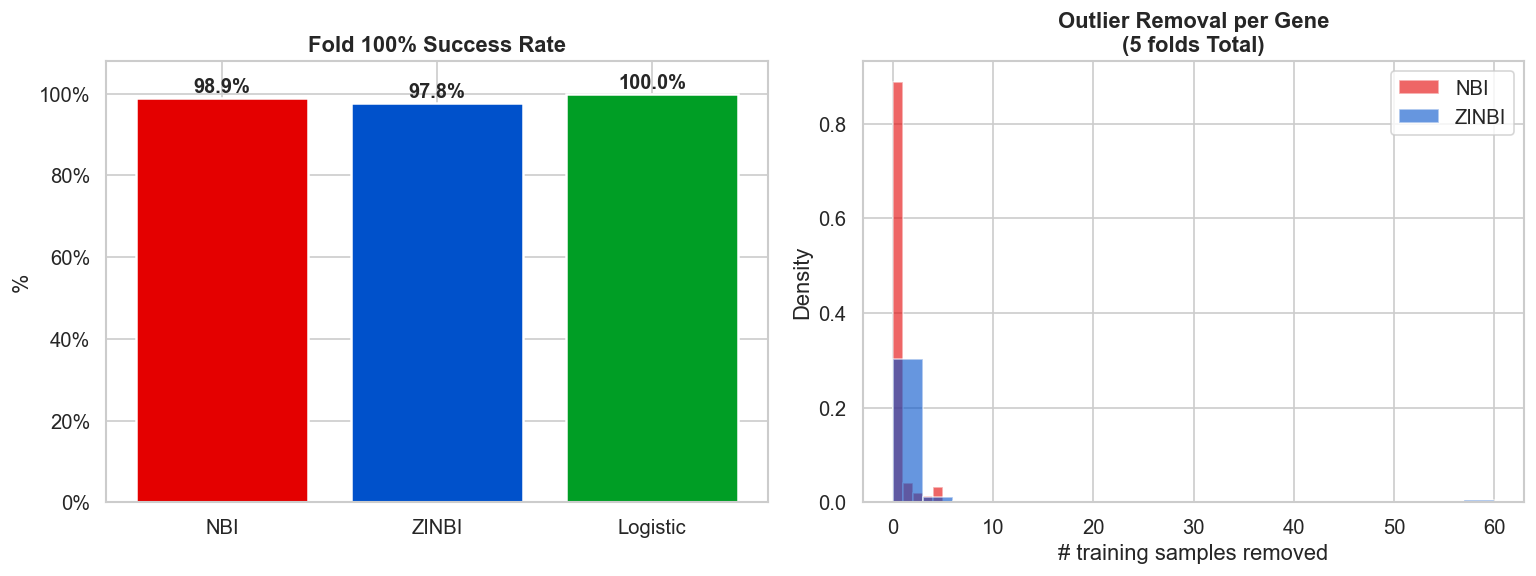

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Fold 100% success rate per model ────────────────────────
ax = axes[0]
fold_ok_full = (all_df.groupby('model')['fold_ok']
                .apply(lambda x: (x == 1.0).mean() * 100)
                .reindex(models_present))
bars = ax.bar(fold_ok_full.index, fold_ok_full.values,
              color=[palette[m] for m in fold_ok_full.index], edgecolor='white', linewidth=1.5)
for bar, v in zip(bars, fold_ok_full.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylim(0, 108)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title('Fold 100% Success Rate', fontweight='bold')
ax.set_ylabel('%')

# ── Right: Outlier removed per gene ──────────────────────────────
ax = axes[1]
for model in [m for m in models_present if m != 'Logistic']:
    vals = all_df[all_df['model'] == model]['n_removed'].clip(0, 60)
    ax.hist(vals, bins=20, alpha=0.6, label=model, color=palette[model], density=True)
ax.set_title('Outlier Removal per Gene\n(5 folds Total)', fontweight='bold')
ax.set_xlabel('# training samples removed')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_fold_outlier.png', bbox_inches='tight')
plt.show()

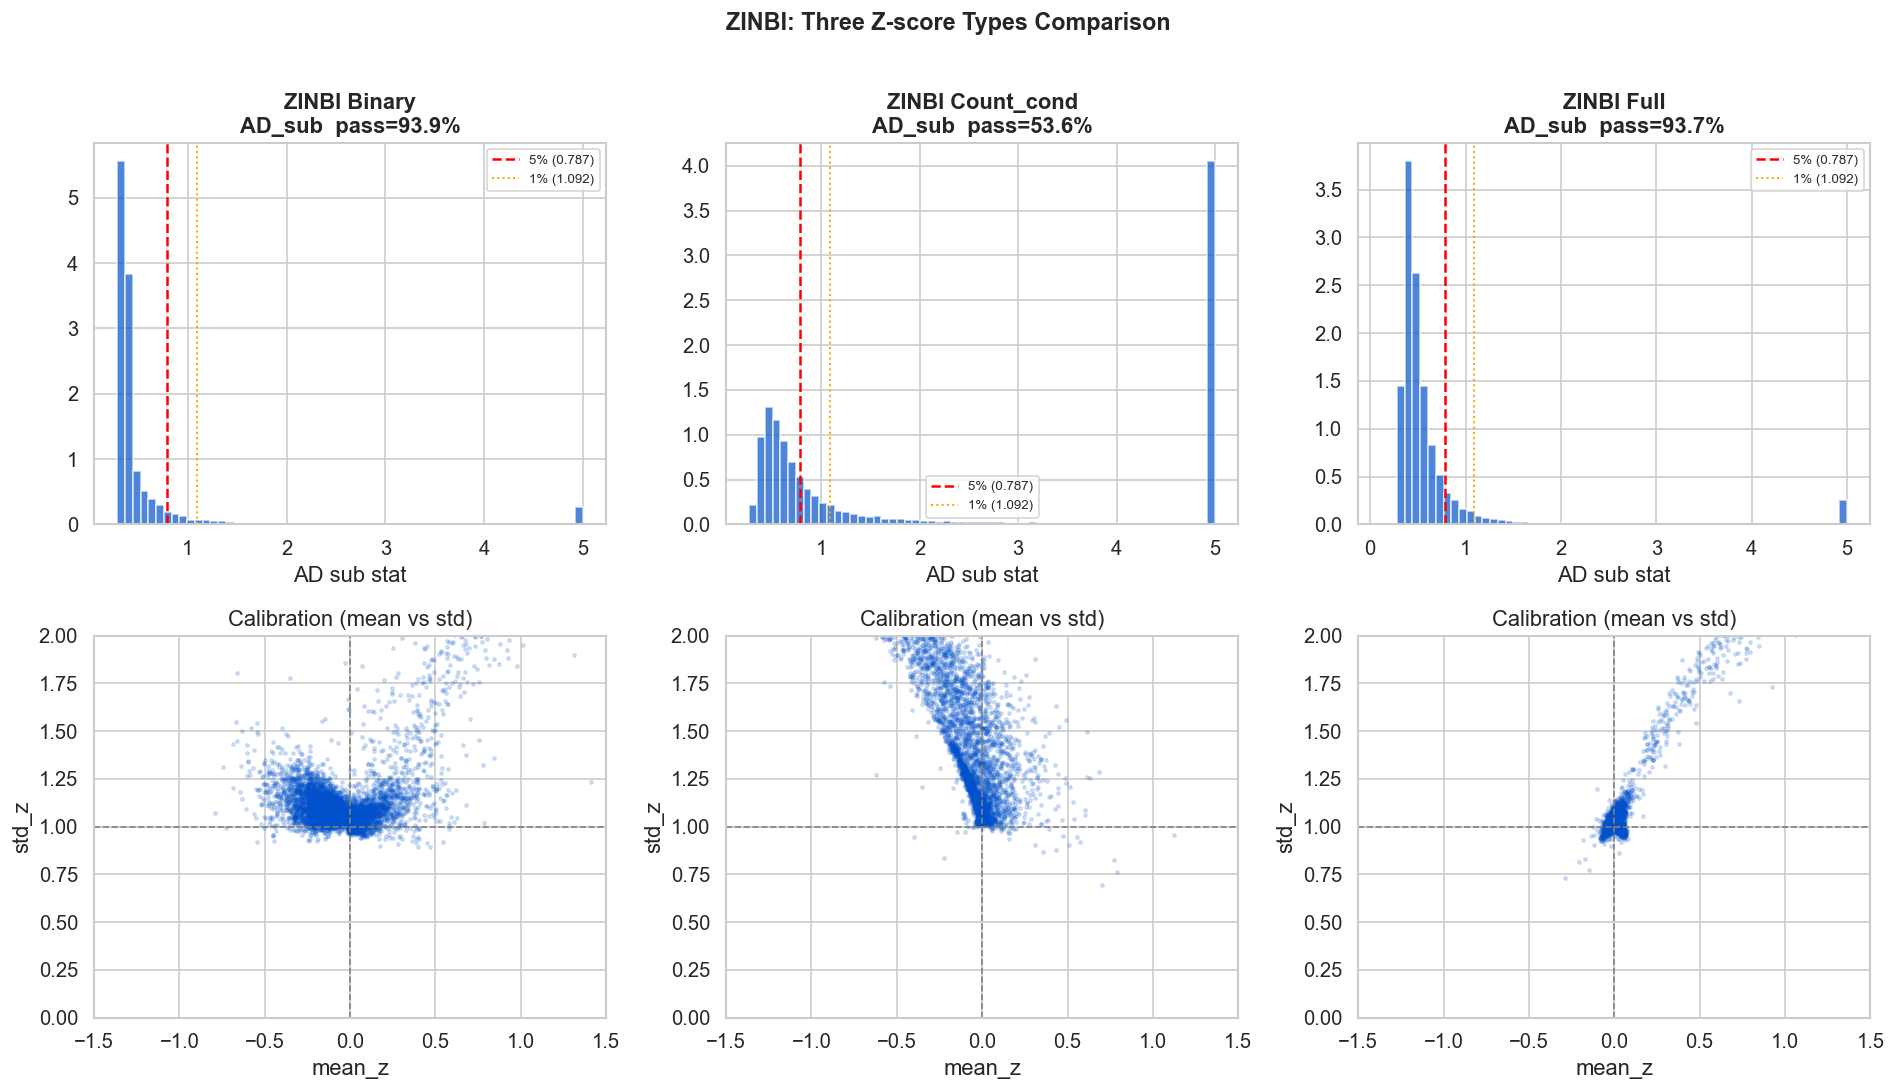

In [38]:
if zinb is not None:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    zscore_types = [
        ('Binary',    'ads_binary',    'ads_binary_pass',    'mean_binary_z',    'std_binary_z'),
        ('Count_cond','ads_count_cond','ads_count_cond_pass','mean_count_cond_z','std_count_cond_z'),
        ('Full',      'ads_full',      'ads_full_pass',      'mean_full_z',      'std_full_z'),
    ]

    for col_idx, (ztype, ad_col, pass_col, mz_col, sz_col) in enumerate(zscore_types):
        ax_ad = axes[0, col_idx]
        ax_cal = axes[1, col_idx]

        # AD distribution
        vals = zinb[ad_col].dropna().clip(0, 5)
        ax_ad.hist(vals, bins=60, color=palette['ZINBI'], alpha=0.7, density=True)
        ax_ad.axvline(0.787, color='red',   lw=1.5, ls='--', label='5% (0.787)')
        ax_ad.axvline(1.092, color='orange',lw=1.2, ls=':',  label='1% (1.092)')
        pass_rate = zinb[pass_col].mean() * 100
        ax_ad.set_title(f'ZINBI {ztype}\nAD_sub  pass={pass_rate:.1f}%', fontweight='bold')
        ax_ad.set_xlabel('AD sub stat'); ax_ad.legend(fontsize=8)

        # Mean/Std scatter
        mz = zinb[mz_col].dropna()
        sz = zinb[sz_col].dropna()
        idx = mz.index.intersection(sz.index)
        ax_cal.scatter(mz[idx], sz[idx], alpha=0.15, s=4, color=palette['ZINBI'])
        ax_cal.axvline(0, color='grey', lw=1, ls='--')
        ax_cal.axhline(1, color='grey', lw=1, ls='--')
        ax_cal.set_xlim(-1.5, 1.5); ax_cal.set_ylim(0, 2)
        ax_cal.set_xlabel('mean_z'); ax_cal.set_ylabel('std_z')
        ax_cal.set_title(f'Calibration (mean vs std)')

    plt.suptitle('ZINBI: Three Z-score Types Comparison', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_zinbi_zscore_types.png', bbox_inches='tight')
    plt.show()
else:
    print('ZINBI results not yet available.')

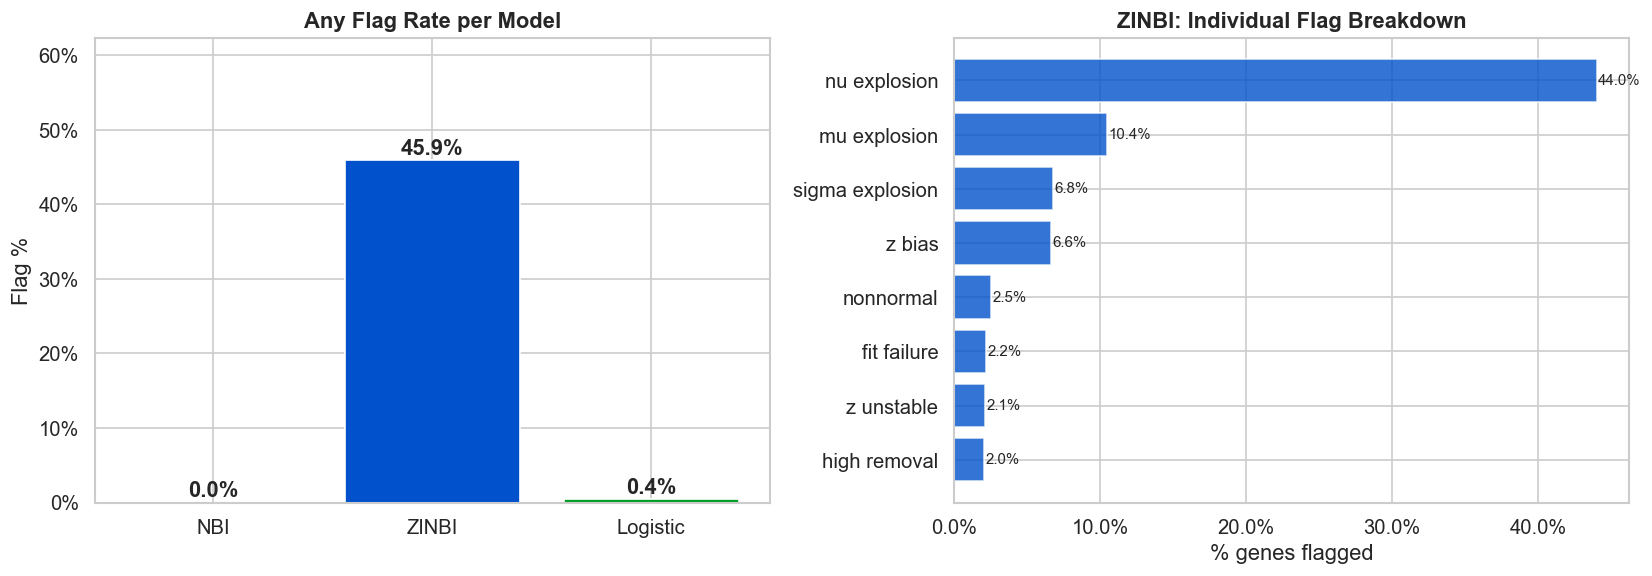

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Flag rate per model ───────────────────────────────────────────
ax = axes[0]
flag_rates = (all_df.groupby('model')['any_flag'].mean() * 100).reindex(models_present)
bars = ax.bar(flag_rates.index, flag_rates.values,
              color=[palette[m] for m in flag_rates.index], edgecolor='white')
for bar, v in zip(bars, flag_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3, f'{v:.1f}%',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Any Flag Rate per Model', fontweight='bold')
ax.set_ylabel('Flag %'); ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(flag_rates.values) * 1.25 + 5)

# ── ZINBI flag breakdown ──────────────────────────────────────────
ax = axes[1]
if zinb is not None:
    flag_cols = [c for c in zinb.columns if c.startswith('flag_') and c != 'any_flag']
    flag_pcts = (zinb[flag_cols].mean() * 100).sort_values(ascending=True)
    flag_labels = [c.replace('flag_', '').replace('_', ' ') for c in flag_pcts.index]
    ax.barh(flag_labels, flag_pcts.values, color=palette['ZINBI'], alpha=0.8)
    ax.set_title('ZINBI: Individual Flag Breakdown', fontweight='bold')
    ax.set_xlabel('% genes flagged')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    for i, v in enumerate(flag_pcts.values):
        ax.text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)
elif logr is not None:
    flag_cols = [c for c in logr.columns if c.startswith('flag_') and c != 'any_flag']
    flag_pcts = (logr[flag_cols].mean() * 100).sort_values(ascending=True)
    flag_labels = [c.replace('flag_', '').replace('_', ' ') for c in flag_pcts.index]
    ax.barh(flag_labels, flag_pcts.values, color='#55A868', alpha=0.8)
    ax.set_title('Logistic: Individual Flag Breakdown', fontweight='bold')

plt.tight_layout()
plt.savefig(CV_DIR / 'fig_flags.png', bbox_inches='tight')
plt.show()

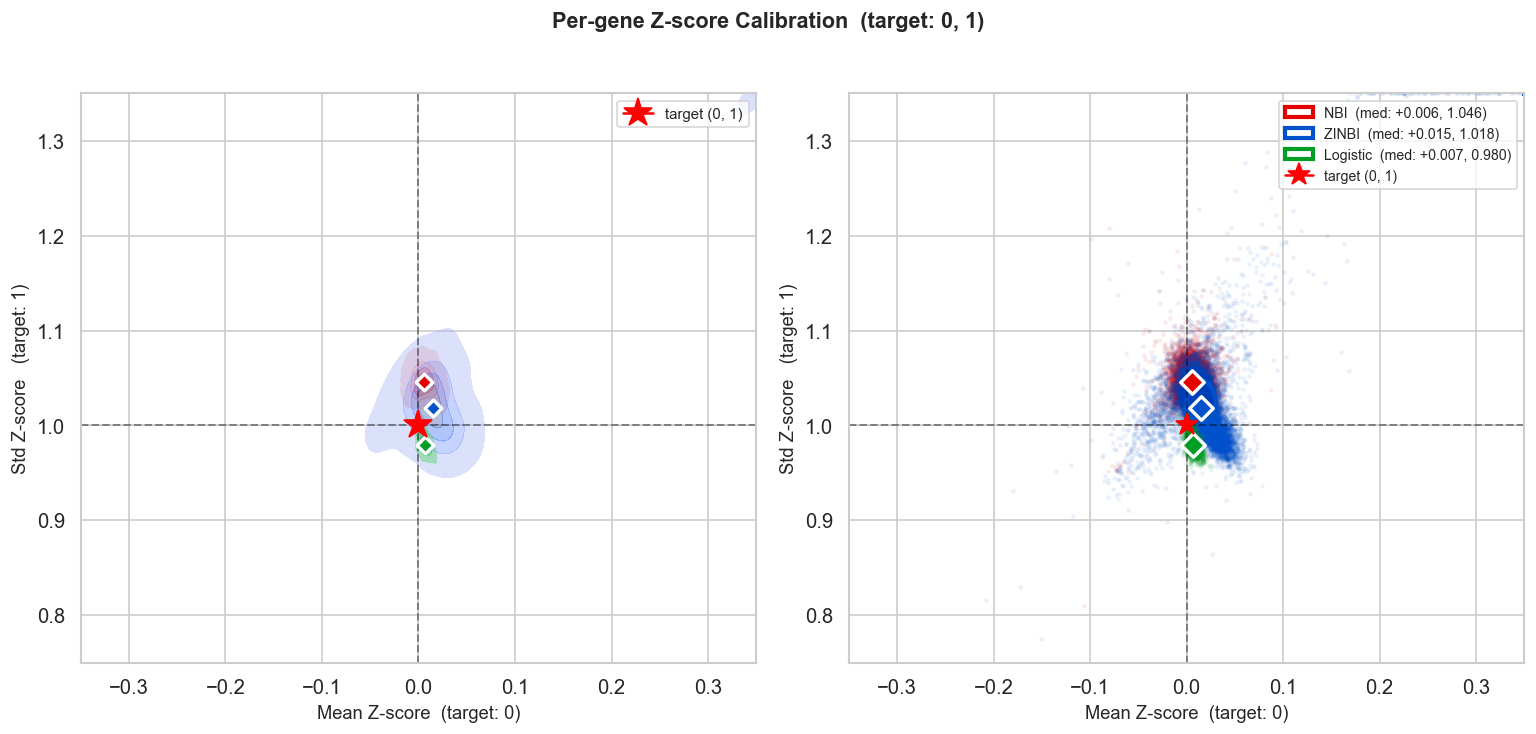

Model         med mean_z  med std_z  |mean_z|<0.1 %  |std_z-1|<0.1 %
------------------------------------------------------------------
NBI              +0.0055     1.0456          100.0%            99.6%
ZINBI            +0.0152     1.0184           97.3%            96.3%
Logistic         +0.0065     0.9797          100.0%           100.0%


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
xlim = (-0.35, 0.35)
ylim = (0.75, 1.35)
# ── Left: 2D KDE contour ──────────────────────────────────────────
ax = axes[0]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)
    sns.kdeplot(x=mz, y=sz, ax=ax, label=model,
                color=palette[model], levels=5,
                fill=True, alpha=0.40, linewidths=1.5)
    ax.scatter(mz.median(), sz.median(), color=palette[model],
               s=50, zorder=6, edgecolors='white', linewidth=2,
               marker='D')
ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=18, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)', fontsize=11)
ax.set_ylabel('Std Z-score   (target: 1)', fontsize=11)
ax.legend(fontsize=9)

# ── Right: 투명 산점도 + IQR 타원 ────────────────────────────────
ax = axes[1]
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    mz  = sub['mean_z'].clip(*xlim)
    sz  = sub['std_z'].clip(*ylim)

    ax.scatter(mz, sz, alpha=0.05, s=4, color=palette[model])

    # IQR 기반 집중도 타원
    q25_mz, q75_mz = mz.quantile(0.25), mz.quantile(0.75)
    q25_sz, q75_sz = sz.quantile(0.25), sz.quantile(0.75)
    ellipse = plt.matplotlib.patches.Ellipse(
        xy=(mz.median(), sz.median()),
        width=(q75_mz - q25_mz) * 1.5,
        height=(q75_sz - q25_sz) * 1.5,
        edgecolor=palette[model], facecolor='none', lw=2.5,
        label=f'{model}  (med: {mz.median():+.3f}, {sz.median():.3f})'
    )
    ax.add_patch(ellipse)
    ax.scatter(mz.median(), sz.median(), color=palette[model],
               s=100, zorder=6, edgecolors='white', linewidth=2, marker='D')

ax.axvline(0, color='black', lw=1.2, ls='--', alpha=0.4)
ax.axhline(1, color='black', lw=1.2, ls='--', alpha=0.4)
ax.plot(0, 1, marker='*', ms=14, color='red', zorder=7, label='target (0, 1)')
ax.set_xlim(*xlim); ax.set_ylim(*ylim)
ax.set_xlabel('Mean Z-score  (target: 0)', fontsize=11)
ax.set_ylabel('Std Z-score   (target: 1)', fontsize=11)
ax.legend(fontsize=8.5, loc='upper right')

plt.suptitle('Per-gene Z-score Calibration  (target: 0, 1)',
             y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(CV_DIR / 'fig_calibration_2d.png', bbox_inches='tight')
plt.show()

# ── 수치 요약 ────────────────────────────────────────────────────
print(f"{'Model':<12} {'med mean_z':>11} {'med std_z':>10} "
      f"{'|mean_z|<0.1 %':>15} {'|std_z-1|<0.1 %':>16}")
print('-' * 66)
for model in models_present:
    sub = all_df[all_df['model'] == model].dropna(subset=['mean_z', 'std_z'])
    m   = sub['mean_z'].median()
    s   = sub['std_z'].median()
    pm  = (sub['mean_z'].abs() < 0.1).mean() * 100
    ps  = ((sub['std_z'] - 1).abs() < 0.1).mean() * 100
    print(f"{model:<12} {m:>+11.4f} {s:>10.4f} {pm:>14.1f}% {ps:>15.1f}%")

In [43]:
print('=' * 65)
print('  Model Performance Summary')
print('=' * 65)

for model in models_present:
    sub = all_df[all_df['model'] == model]
    n   = len(sub)
    ad_pass   = sub['ad_pass'].mean() * 100
    fold_ok   = (sub['fold_ok'] == 1.0).mean() * 100
    med_ad    = sub['ad_sub'].median()
    med_mean  = sub['mean_z'].median()
    med_std   = sub['std_z'].median()
    flag_rate = sub['any_flag'].mean() * 100

    print(f"\n[{model}]  {n:,} genes")
    print(f"  AD pass rate  : {ad_pass:.1f}%   (higher = better)")
    print(f"  Fold ok rate  : {fold_ok:.1f}%   (target: 100%)") 
    print(f"  Median AD_sub : {med_ad:.3f}    (lower = closer to N(0,1))")
    print(f"  Median mean_z : {med_mean:+.4f}  (target: 0.0)")
    print(f"  Median std_z  : {med_std:.4f}   (target: 1.0)")
    print(f"  Flag rate     : {flag_rate:.1f}%   (lower = better)")

print('\n' + '=' * 65)
print('Generated figures → CV_Results/fig_*.png')
print('=' * 65)

  Model Performance Summary

[NBI]  15,185 genes
  AD pass rate  : 89.5%   (higher = better)
  Fold ok rate  : 98.9%   (target: 100%)
  Median AD_sub : 0.604    (lower = closer to N(0,1))
  Median mean_z : +0.0055  (target: 0.0)
  Median std_z  : 1.0456   (target: 1.0)
  Flag rate     : 0.0%   (lower = better)

[ZINBI]  15,185 genes
  AD pass rate  : 93.7%   (higher = better)
  Fold ok rate  : 97.8%   (target: 100%)
  Median AD_sub : 0.466    (lower = closer to N(0,1))
  Median mean_z : +0.0152  (target: 0.0)
  Median std_z  : 1.0184   (target: 1.0)
  Flag rate     : 45.9%   (lower = better)

[Logistic]  2,762 genes
  AD pass rate  : 100.0%   (higher = better)
  Fold ok rate  : 100.0%   (target: 100%)
  Median AD_sub : 0.362    (lower = closer to N(0,1))
  Median mean_z : +0.0065  (target: 0.0)
  Median std_z  : 0.9797   (target: 1.0)
  Flag rate     : 0.4%   (lower = better)

Generated figures → CV_Results/fig_*.png


## 9. Posterior Predictive Check (PPC) — NBI vs ZINBI

각 HC 샘플 i가 **test fold에 있을 때** 학습된 파라미터로 카운트를 시뮬레이션하고 실측과 비교합니다.

| 모델 | 파라미터 pkl | 시뮬레이션 |
|---|---|---|
| NBI | `cv_gamlss_nb_ppc.pkl` | Y_sim ~ NBI(μ_i, σ_i) |
| ZINBI | `cv_zinb_ppc.pkl` | Y_sim ~ ZINBI(μ_i, σ_i, ν_i) |

pkl이 없으면 해당 CV 스크립트를 `--no-resume`으로 재실행해야 합니다.

In [ ]:
import scanpy as sc, pickle
from scipy.sparse import issparse

H5AD = Path('..') / 'OpenAccess_nfcore' / \
       'Merged_Processed_AnnData_with_Batch_Biases_QC_Status.h5ad'

# ── PPC 파라미터 로드 ─────────────────────────────────────────────
def load_ppc_pkl(path):
    if not path.exists():
        print(f"  없음: {path.name}")
        return None
    with open(path, 'rb') as f:
        data = pickle.load(f)
    g0 = next(iter(data))
    print(f"  {path.name}: {len(data):,}genes  keys={list(data[g0].keys())}")
    return data

print("PPC parameter files:")
ppc_raw = {
    'NBI':   load_ppc_pkl(CV_DIR / 'cv_gamlss_nb_ppc.pkl'),
    'ZINBI': load_ppc_pkl(CV_DIR / 'cv_zinb_ppc.pkl'),
}
ppc_raw = {k: v for k, v in ppc_raw.items() if v is not None}

# ── HC 실측 카운트 로드 (공유) ────────────────────────────────────
if ppc_raw:
    print("\nLoading HC counts from h5ad...")
    adata = sc.read_h5ad(H5AD)
    adata = adata[adata.obs['QC_Passed'] == True]
    adata = adata[adata.obs['Phenotype_Processed'].notna()]
    adata = adata[adata.obs['Phenotype_Processed'] != 'Unknown']
    is_hc = (adata.obs['Phenotype_Processed'].astype(str) == 'Healthy Control').values
    Y     = adata.X[is_hc]
    if issparse(Y): Y = Y.toarray()
    Y     = np.round(Y).astype(np.float32)
    gene_idx = {g: i for i, g in enumerate(adata.var_names)}
    print(f"  HC={is_hc.sum()}, genes={len(gene_idx):,}")

# ── 시뮬레이션 함수 ───────────────────────────────────────────────
def simulate_nbi(mu, sigma, seed=42):
    rng   = np.random.default_rng(seed)
    sigma = np.maximum(sigma, 1e-8)
    theta = 1.0 / sigma
    p     = np.clip(theta / (theta + mu), 1e-8, 1 - 1e-8)
    return rng.negative_binomial(theta, p).astype(np.float32)

def simulate_zinbi(mu, sigma, nu, seed=42):
    """ZINBI: structural zeros(ν) + NBI count component."""
    rng   = np.random.default_rng(seed)
    n     = len(mu)
    sigma = np.maximum(sigma, 1e-8)
    nu    = np.clip(nu, 0, 1)
    theta = 1.0 / sigma
    p     = np.clip(theta / (theta + mu), 1e-8, 1 - 1e-8)
    y_nbi = rng.negative_binomial(theta, p)
    is_zero = rng.uniform(size=n) < nu      # structural zero mask
    return np.where(is_zero, 0, y_nbi).astype(np.float32)

SIM_FN = {
    'NBI':   lambda params, seed: simulate_nbi(params['mu'], params['sigma'], seed),
    'ZINBI': lambda params, seed: simulate_zinbi(
                 params['mu'], params['sigma'], params['nu'], seed),
}

# ── PPC 통계량 계산 ───────────────────────────────────────────────
ppc_dfs = {}
for model, raw in ppc_raw.items():
    records, seed = [], 42
    for gene, params in raw.items():
        gi = gene_idx.get(gene, -1)
        if gi < 0: continue
        y     = Y[:, gi]
        valid = np.isfinite(params['mu']) & np.isfinite(params['sigma'])
        if 'nu' in params:
            valid &= np.isfinite(params['nu'])
        if valid.sum() < 10: continue

        p_v   = {k: v[valid] for k, v in params.items()}
        y_v   = y[valid]
        y_sim = SIM_FN[model](p_v, seed)

        records.append({
            'gene':      gene,
            'real_mean': y_v.mean(),        'sim_mean': y_sim.mean(),
            'real_std':  y_v.std(),         'sim_std':  y_sim.std(),
            'real_det':  (y_v > 0).mean(),  'sim_det':  (y_sim > 0).mean(),
            'n_valid':   valid.sum(),
        })
        seed += 1

    ppc_dfs[model] = pd.DataFrame(records)
    print(f"{model}: PPC computed for {len(ppc_dfs[model]):,} genes")

if ppc_dfs:
    cols = ['real_mean','sim_mean','real_std','sim_std','real_det','sim_det']
    for model, df in ppc_dfs.items():
        print(f"\n── {model} ──")
        display(df[cols].describe().round(3))

In [ ]:
if not ppc_dfs:
    print("PPC 데이터 없음. CV 스크립트를 --no-resume으로 재실행 후 다시 시도.")
else:
    ppc_models = list(ppc_dfs.keys())
    n_models   = len(ppc_models)

    stats = [
        ('real_mean', 'sim_mean', 'Mean Count',      'log'),
        ('real_std',  'sim_std',  'Standard Deviation', 'log'),
        ('real_det',  'sim_det',  'Detection Rate',  'linear'),
    ]

    fig, axes = plt.subplots(3, n_models,
                              figsize=(6 * n_models, 16), squeeze=False)

    for col, model in enumerate(ppc_models):
        df    = ppc_dfs[model].dropna()
        color = palette.get(model, '#888888')
        n_g   = len(df)

        for row, (rx, sy, title, scale) in enumerate(stats):
            ax = axes[row, col]
            x  = df[rx].clip(lower=1e-3)
            y  = df[sy].clip(lower=1e-3)

            ax.scatter(x, y, alpha=0.10, s=4, color=color, rasterized=True)

            lo = min(x.quantile(0.005), y.quantile(0.005))
            hi = max(x.quantile(0.995), y.quantile(0.995))
            ax.plot([lo, hi], [lo, hi], 'k--', lw=1.8, label='y = x')

            v     = np.isfinite(x) & np.isfinite(y)
            corr  = np.corrcoef(x[v], y[v])[0, 1]
            rmse  = np.sqrt(((x[v] - y[v]) ** 2).mean())
            bias  = (y[v] - x[v]).mean()
            ax.text(0.04, 0.96,
                    f'r = {corr:.4f}\nRMSE = {rmse:.3f}\nBias = {bias:+.3f}',
                    transform=ax.transAxes, fontsize=10, va='top',
                    bbox=dict(boxstyle='round,pad=0.4', fc='white', alpha=0.85))

            if scale == 'log':
                ax.set_xscale('log'); ax.set_yscale('log')

            ax.set_xlabel('Real (HC)', fontsize=11)
            ax.set_ylabel(f'Simulated ({model})', fontsize=11)
            ax.set_title(f'{model}  —  {title}', fontweight='bold', fontsize=12)
            ax.legend(fontsize=9)

    plt.suptitle(
        f'PPC — NBI vs ZINBI  (HC = 996 samples)\n'
        f'각 샘플 i: test fold 파라미터 → 시뮬레이션 → 실측 비교',
        fontsize=13, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.savefig(CV_DIR / 'fig_ppc_fold.png', bbox_inches='tight', dpi=150)
    plt.show()

    # ── 수치 요약 비교표 ───────────────────────────────────────────
    print(f"\n{'Model':<8} {'Statistic':<22} {'r':>8} {'RMSE':>10} {'Bias':>12}")
    print('─' * 64)
    for model in ppc_models:
        df = ppc_dfs[model].dropna()
        for rx, sy, label, _ in stats:
            x, y_ = df[rx].values, df[sy].values
            v      = np.isfinite(x) & np.isfinite(y_)
            corr   = np.corrcoef(x[v], y_[v])[0, 1]
            rmse   = np.sqrt(((x[v] - y_[v]) ** 2).mean())
            bias   = (y_[v] - x[v]).mean()
            print(f"{model:<8} {label:<22} {corr:>8.4f} {rmse:>10.3f} {bias:>+12.3f}")
        print()